# Analysint QM7 using TDAF in tf1

This comes from the benchmarking code in deepchem 2.3, tf 1, as run on the linux box.

In [425]:
import sys
sys.path.append(r"C:\Users\ella_\Documents\GitHub\graphs_and_topology_for_chemistry")
sys.path.append(r"C:\Users\ella_\Documents\GitHub\icosahedron_projection")

import deepchem as dc
#from deepchem.feat import SmilesToImage

import tensorflow as tf
import os
import sys
import rdkit
import h5py
import helper_functions as h
import pandas

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.tri
import rdkit.Chem as Chem
import rdkit.Chem.AllChem as AllChem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors
import mpl_toolkits.mplot3d
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from collections import Counter

print("TensorFlow version: " + tf.__version__)

# topology stuff
from gtda.plotting import plot_point_cloud
from gtda.homology import VietorisRipsPersistence
from gtda.plotting import plot_diagram
from gtda.diagrams import PersistenceEntropy
from gtda.diagrams import NumberOfPoints
from gtda.diagrams import Amplitude
from sklearn.pipeline import make_union, Pipeline

# fixc this at some point
sys.path.append(r"C:\Users\ella_\Documents\GitHub\graphs_and_topology_for_chemistry")
sys.path.append(r"C:\Users\ella_\Documents\GitHub\icosahedron_projection")

import projection
#from projection.molecule import Molecule
#from projection.pdbmolecule import PDBMolecule
#from projection.mol2molecule import Mol2Molecule

import helper_functions as h
loaders, classification_datasets, regression_datasets, metric_types = h.deepchem_dataset_dictionaries()

# change THIS

dataset_name='qm7'

data_dir=r'F:\Nextcloud\science\Datasets\topol_datasets'
results_dir=r"F:\Nextcloud\science\results\topology_and_graphs\d_" + dataset_name
test_file=dataset_name + '.csv'
data_file_name=dataset_name + '_topological_features.hdf5'
loader = loaders[dataset_name]
make_dataset=False # whether to recalc the dataset

print(f"DeepChem version: {dc.__version__}")

############################### settings for all experiments #################

best_con = 123.7 #multitask value   #10.22
best_graph = 8.8 # for dtnn, u didn't run ani which is 2.86

num_repeats= 5
num_epochs = 500

metric_labels=['mean_squared_error','pearson_r2_score',
               'mae_score', 'rmse']


metric1 = dc.metrics.Metric(dc.metrics.mean_squared_error)
metric2 = dc.metrics.Metric(dc.metrics.pearson_r2_score)
metric3 = dc.metrics.Metric(dc.metrics.mae_score)
metrics = [metric1, metric2, metric3]
selected_metric = 2 #which metric to use for callback

Splitter = dc.splits.SingletaskStratifiedSplitter()

split_fraction=[0.1, 0.1, 0.8]


TensorFlow version: 2.7.0
DeepChem version: 2.5.0


In [428]:
def method_comparison_plotter(
    list_of_dataframes,
    list_of_columns,
    color_list,
    exclusion_list = [],
    df_exclusion_list= [],
    label_list=[],
    best_con=None,
    best_con_error=None,
    best_gr=None,
    best_gr_error=None,
    x_label='',
    y_label='',
    filename='method_comparison',
    rider='all_data.png'):
    
    """Plotter
    list of data frames: list of results
    list_of_columns: which matrics to use (columsn in df)
    color_list = which colours to use
    exclusion_list: whether to miss out a df - either cos missing or unwanted
    df_exclusion_list: whether to miss out a column ONLY if not missing
    label_list: labels per dataset
    best_con: best 1D method
    best_con_error: std err
    best_gr: best graph method
    best_gr_error=None,
    x_label='',
    y_label='',
    filename='method_comparison',
    rider='all_data.png')"""
    
    #Best=1.92
    # pick subset of colours
    if color_list == None:
        color_list=["#1f77f4","#f62728", # red blue ecfp
                   "#1f77f4","#f62728", #maccs
                   "#1f77f4","#f62728", # rdkit
                   "#88fff4","#552200", #brown green # cmeig
                   "#61ff33","#ffb433", # green orange #sm2img
                   "#61ff33","#ffb433", # gc
                   "#61ff33","#ffb433",      #weave         
                   "#88fff4","#552200", #brown green    #cm           
                   "#5f77f4","#f62788", # pink blue tdaf
                   "#5f77f4","#f62788"] # pca-tdaf
    # get subset of labels
    if label_list == None:
            label_list=['ECFP',
                "MACCS",
                "rdkit",
                "CM_eig",
                'Sm2Img', 
                'GC', 
                'Weave', 
                'CM',
                "TDAF",
                "PCA-TDAF"]
    if exclusion_list:
        color_exclusion_list=[]
        for excluded in exclusion_list:
            for i in range(len(list_of_columns)):
                color_exclusion_list.append((excluded*len(list_of_columns))+i)
        print(color_exclusion_list)
        color_list = [color_list[i] for i in range(len(color_list)) if i not in color_exclusion_list]
        print(color_list)
        # subset of labels
        egg=[label_list[i] for i in range(len(label_list)) if i not in exclusion_list]
        label_list=egg

    data=[]
    for df_no in range(len(list_of_dataframes)):
        if df_no not in df_exclusion_list:
            df=list_of_dataframes[df_no]
            for col in list_of_columns:
                data.append(df[col])

    # calc and jot down the means
    print(len(data))
    means=[np.mean(x) for x in data]
    stds=[np.std(x) for x in data]
    egg= {'means': means, 'stds': stds}
    df2 = pd.DataFrame(egg) 
    # saving the dataframe 
    sigh=rider.split('.')[0]
    df2.to_csv(os.path.join(results_dir, 'means_stds_in_plot_' + filename + sigh + 'csv'))

    x_positions = [x+1 for x in range(len(means))]
    ax=plt.figure(figsize=(16, 9))
    plt.rcParams.update({'font.size': 22})

    plt.bar(x_positions, means, 
        color=color_list,
        edgecolor='k',
        linewidth='3',
        yerr=stds, 
        error_kw=dict(lw=5, capsize=15, capthick=3))

    for i in range(len(means)):
        x=data[i]; plt.plot(np.ones(len(x))*(i+1),x,'o',color="#444444")


    #axes.set_ylim([0.5,4.5])
    #axes.set_xlim([0.45,4.55])
    x_tick_list=[x*2+1.5 for x in range(len(label_list))]
    #[1.5,3.5,5.5,7.5,9.5,11.5,13.5,15.5,17.5,19.5]

    #x_tick_list = x_tick_list[:len(label_list)]
    plt.xticks(x_tick_list,
               label_list,
               rotation=90)
    if best_con:
        plt.plot([0.5,max(x_tick_list)+1],[best_con, best_con],'k',linewidth=4,linestyle='dashed')
    
    if best_con_error:
        plt.plot([0.5,max(x_tick_list)+1],[best_con+best_con_error, best_con+best_con_error],'grey',linewidth=4,linestyle='dotted')
        plt.plot([0.5,max(x_tick_list)+1],[best_con-best_con_error, best_con-best_con_error],'grey',linewidth=4,linestyle='dotted')

    if best_gr:
        plt.plot([0.5,max(x_tick_list)+1],[best_graph, best_graph],'g',linewidth=4,linestyle='dashed')
    
    if best_gr_error:
        plt.plot([0.5,max(x_tick_list)+1],[best_graph+best_graph_error, best_graph+best_graph_error],'darkseagreen',linewidth=4,linestyle='dotted')
        plt.plot([0.5,max(x_tick_list)+1],[best_graph-best_graph_error, best_graph-best_graph_error],'darkseagreen',linewidth=4,linestyle='dotted')

    axes=plt.gca()
    plt.ylabel(y_label)
    plt.xlabel(x_label)
    plt.savefig(os.path.join(results_dir, filename + rider))
    return ax, means, stds

In [374]:
len(all_dfs)

9

In [375]:
[x+1.5 for x in range(len(all_dfs))]

[1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5]

In [376]:
tdaf_qm7_df=pd.read_csv(os.path.join(results_dir, 'tdaf_qm7_results.csv'), header=None)
tdaf_qm7_df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,tdaf_qm7,None,regression,rf_regression,mean-mean_squared_error,train,5933.357637,valid,40059.232908,test,44156.149620,time_for_running,8.991213
1,tdaf_qm7,None,regression,rf_regression,mean-pearson_r2_score,train,0.938584,valid,0.187532,test,0.122454,time_for_running,8.991213
2,tdaf_qm7,None,regression,rf_regression,mean-mae_score,train,61.445568,valid,161.429130,test,165.394352,time_for_running,8.991213
3,tdaf_qm7,None,regression,rf_regression,mean-rms_score,train,77.028291,valid,200.148027,test,210.133647,time_for_running,8.991213
4,tdaf_qm7,None,regression,textcnn_regression,mean-mean_squared_error,train,3320.323275,valid,59824.677178,test,60353.800578,time_for_running,191.297168


In [377]:
qm7_df=pd.read_csv(os.path.join(results_dir, 'results.csv'),header=None)
qm7_df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,qm7,None,regression,tf_regression,mean-mean_squared_error,train,17843.000768,valid,23624.586531,test,20530.621605,time_for_running,9.693066
1,qm7,None,regression,tf_regression,mean-pearson_r2_score,train,0.638705,valid,0.518532,test,0.580388,time_for_running,9.693066
2,qm7,None,regression,tf_regression,mean-mae_score,train,96.892661,valid,113.390012,test,107.419893,time_for_running,9.693066
3,qm7,None,regression,tf_regression,mean-rms_score,train,133.577696,valid,153.702916,test,143.285106,time_for_running,9.693066
4,qm7,None,regression,tf_regression,mean-mean_squared_error,train,18828.507832,valid,24004.473540,test,21393.550719,time_for_running,9.365499


In [378]:
from collections import Counter
Counter(qm7_df[3])

Counter({'tf_regression': 80,
         'tf_regression_ft': 80,
         'rf_regression': 80,
         'graphconvreg': 80,
         'dtnn': 80,
         'weave_regression': 80,
         'textcnn_regression': 80,
         'krr': 40,
         'krr_ft': 40})

In [379]:
model_name_list = [x for x in Counter(qm7_df[3]).keys()]
tdaf_model_name_list = [x for x in Counter(tdaf_qm7_df[3]).keys()]
tf1_dataset_name = 'qm7'
tf1_model_name = model_name_list[0]
dataframe_name_list = [tf1_dataset_name + '_' + x +'_df' for x in model_name_list]
tr_te_val_col_dict={'tr':6, 'val':8, 'te':10, 'time':12}

In [380]:
Counter(qm7_df[4])

Counter({'mean-mean_squared_error': 160,
         'mean-pearson_r2_score': 160,
         'mean-mae_score': 160,
         'mean-rms_score': 160})

In [381]:
metric_dictionary = {'tr_mse':'mean-mean_squared_error',
               'tr_r2':'mean-pearson_r2_score',
               'tr_mae':'mean-mae_score',
               'tr_rmse':'mean-rms_score',
               'val_mse':'mean-mean_squared_error',
               'val_r2':'mean-pearson_r2_score',
               'val_mae':'mean-mae_score',
               'val_rmse':'mean-rms_score',
               'te_mse':'mean-mean_squared_error',
               'te_r2':'mean-pearson_r2_score',
               'te_mae':'mean-mae_score',
               'te_rmse':'mean-rms_score'}
metric_list=['tr_mse','tr_r2','tr_mae','tr_rmse',
               'val_mse','val_r2','val_mae','val_rmse',
               'te_mse','te_r2','te_mae','te_rmse']

In [382]:
list_of_dataframes=[qm7_tf_regression_df,
 qm7_tf_regression_ft_df,
 qm7_rf_regression_df,
 qm7_graphconvreg_df,
 qm7_dtnn_df,
 qm7_weave_regression_df,
 qm7_textcnn_regression_df,
 qm7_krr_df,
 qm7_krr_ft_df]

NameError: name 'qm7_tf_regression_ft_df' is not defined

In [383]:
qm7_tf_regression_df= pd.DataFrame(columns=['run'] + metric_list + )
qm7_tf_regression_df

SyntaxError: invalid syntax (Temp/ipykernel_13596/65037301.py, line 1)

In [384]:
model_df

,tr_rmse,te_rmse,val_rmse
0,133.577696,153.702916,143.285106
1,137.217010,154.933771,146.265344
2,134.726269,153.573334,144.383554
3,133.403382,152.942380,143.366633
4,137.166915,155.317007,146.259041
5,136.406294,153.731271,144.844926
6,135.546015,154.226672,145.342252
7,142.215149,159.458256,150.630977
8,136.229775,154.172842,146.001004
9,135.594666,154.700012,145.055148


In [385]:
tr_te_val_col_dict
for current_metric in metric_list:
    print(tr_te_val_col_dict[current_metric.split('_')[0]])

6
6
6
6
8
8
8
8
10
10
10
10


In [386]:
metric_list

['tr_mse',
 'tr_r2',
 'tr_mae',
 'tr_rmse',
 'val_mse',
 'val_r2',
 'val_mae',
 'val_rmse',
 'te_mse',
 'te_r2',
 'te_mae',
 'te_rmse']

In [387]:
model_df

,tr_rmse,te_rmse,val_rmse
0,133.577696,153.702916,143.285106
1,137.217010,154.933771,146.265344
2,134.726269,153.573334,144.383554
3,133.403382,152.942380,143.366633
4,137.166915,155.317007,146.259041
5,136.406294,153.731271,144.844926
6,135.546015,154.226672,145.342252
7,142.215149,159.458256,150.630977
8,136.229775,154.172842,146.001004
9,135.594666,154.700012,145.055148


In [388]:
metric_list=['mse',
 'r2',
 'mae',
 'rmse']

In [389]:
old_metric_list=metric_list
old_metric_dictionary=metric_dictionary

In [390]:
metric_dictionary={'mse':'mean-mean_squared_error',
 'r2': 'mean-pearson_r2_score',
 'mae': 'mean-mae_score',
 'rmse': 'mean-rms_score'}

In [391]:
tr_te_val_col_dict

{'tr': 6, 'val': 8, 'te': 10, 'time': 12}

In [392]:
tr_te_val_col_dict = {'tr': 6, 'val': 8, 'te': 10}

In [393]:
run_list = ['tr','te','val']

In [394]:
model_name_list

['tf_regression',
 'tf_regression_ft',
 'rf_regression',
 'graphconvreg',
 'dtnn',
 'weave_regression',
 'textcnn_regression',
 'krr',
 'krr_ft']

In [395]:
def convert_from_dc2p3_validation_output(
    input_df,
    tf1_dataset_name,
    model_name,
    metric_dictionary={
        'mse': 'mean-mean_squared_error',
        'r2': 'mean-pearson_r2_score',
        'mae': 'mean-mae_score',
        'rmse': 'mean-rms_score'}
    ): 
    """Converts from dc2.3 (tf1) benchmark outputs to my dataframe format
    input_df: comes from run_benchmark in dc2.3
    tf1_dataset_name: dataset name in dc2.3
    model_name: name of model from benchmark script & csv file
    metric_dictionary: metrics in my code to metrics in theirs
    """
    print(f"Doing model: {model_name}")
    print(f"Doing dataset: {tf1_dataset_name}")
    qm7_df = input_df
    #model_name_list[0]
    # make empty dataframe with my column headings
    output_columns = []
    for run in run_list:
        for metric in metric_list:
            output_columns.append(f"{run}_{metric}")
    output_columns.append("time")
    #print(output_columns)
    temp_df = pd.DataFrame(columns=output_columns)
    temp_df.reindex(output_columns, axis=1)

    #if True:
    metric_df=[]
    # grab all data for this problem
    dataset_df=qm7_df[qm7_df[0]==tf1_dataset_name]
    # grab only data for this model
    dataset_df=dataset_df[dataset_df[3]==model_name]
    # First do time as it is weird
    time_df=dataset_df[dataset_df[4]==metric_dictionary[metric_list[0]]]
    time_df=time_df[12]
    time_df = time_df.to_frame()
    time_df.columns=["Time"]
    time_df=time_df.reset_index(drop=True)

    for current_metric in metric_list:  
        #print(current_metric)
        #print(f"metric loop:{current_metric}:{metric_dictionary[current_metric]}")

        # create dataset of this model, this metric
        #print(dataset_df)
        model_df=dataset_df[dataset_df[4]==metric_dictionary[current_metric]]
        model_df=model_df[tr_te_val_col_dict.values()].reset_index(drop=True)    
        model_df.columns = [f"tr_{current_metric}",f"te_{current_metric}",f"val_{current_metric}"]        
        time_df = time_df.join(model_df)
    return time_df

In [396]:
list_of_dataframes=[]
for model_name in model_name_list:
    out_df = convert_from_dc2p3_validation_output(
        input_df=qm7_df,
        tf1_dataset_name=tf1_dataset_name,
        model_name=model_name,
        metric_dictionary={
            'mse': 'mean-mean_squared_error',
            'r2': 'mean-pearson_r2_score',
            'mae': 'mean-mae_score',
            'rmse': 'mean-rms_score'}) 
    list_of_dataframes.append(out_df)

Doing model: tf_regression
Doing dataset: qm7
Doing model: tf_regression_ft
Doing dataset: qm7
Doing model: rf_regression
Doing dataset: qm7
Doing model: graphconvreg
Doing dataset: qm7
Doing model: dtnn
Doing dataset: qm7
Doing model: weave_regression
Doing dataset: qm7
Doing model: textcnn_regression
Doing dataset: qm7
Doing model: krr
Doing dataset: qm7
Doing model: krr_ft
Doing dataset: qm7


In [397]:
model_name_list

['tf_regression',
 'tf_regression_ft',
 'rf_regression',
 'graphconvreg',
 'dtnn',
 'weave_regression',
 'textcnn_regression',
 'krr',
 'krr_ft']

In [403]:
model_name_list

['tf_regression',
 'tf_regression_ft',
 'rf_regression',
 'graphconvreg',
 'dtnn',
 'weave_regression',
 'textcnn_regression',
 'krr',
 'krr_ft']

18


Text(0.5, 1.0, 'QM7 tf1 benchmark')

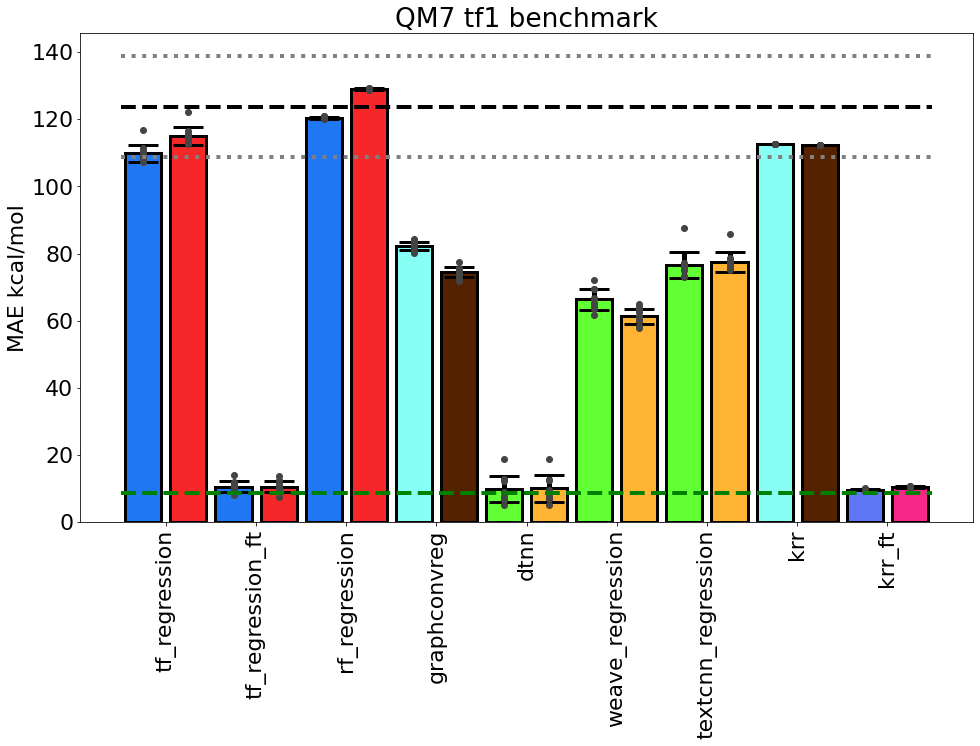

In [429]:
ax, means, stds= method_comparison_plotter(
    list_of_dataframes=list_of_dataframes,
    list_of_columns=['val_mae','te_mae'],
    color_list=None,
    exclusion_list=[],
    filename='tf1_benchmark',
    label_list=model_name_list,
    best_con=best_con,
    best_con_error=15,
    best_gr=best_graph,
    best_gr_error=None,
    x_label='',
    y_label='MAE kcal/mol',
    rider='tf1_benchmark.png')
plt.title('QM7 tf1 benchmark')

In [331]:
tdaf_qm7_df

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,tdaf_qm7,None,regression,rf_regression,mean-mean_squared_error,train,5933.357637,valid,40059.232908,test,44156.149620,time_for_running,8.991213
1,tdaf_qm7,None,regression,rf_regression,mean-pearson_r2_score,train,0.938584,valid,0.187532,test,0.122454,time_for_running,8.991213
2,tdaf_qm7,None,regression,rf_regression,mean-mae_score,train,61.445568,valid,161.429130,test,165.394352,time_for_running,8.991213
3,tdaf_qm7,None,regression,rf_regression,mean-rms_score,train,77.028291,valid,200.148027,test,210.133647,time_for_running,8.991213
4,tdaf_qm7,None,regression,textcnn_regression,mean-mean_squared_error,train,3320.323275,valid,59824.677178,test,60353.800578,time_for_running,191.297168
...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,tdaf_qm7,None,regression,krr,mean-rms_score,train,187.227928,valid,221.020365,test,231.383117,time_for_running,2.926989
128,tdaf_qm7,None,regression,krr,mean-mean_squared_error,train,35054.297009,valid,48850.001530,test,53538.147044,time_for_running,2.931899
129,tdaf_qm7,None,regression,krr,mean-pearson_r2_score,train,0.280155,valid,0.078878,test,0.043162,time_for_running,2.931899
130,tdaf_qm7,None,regression,krr,mean-mae_score,train,143.752501,valid,174.871351,test,178.404734,time_for_running,2.931899


In [409]:
tdaf_list_of_dataframes=[]
for model_name in tdaf_model_name_list:
    out_df = convert_from_dc2p3_validation_output(
        input_df=tdaf_qm7_df,
        tf1_dataset_name='tdaf_qm7',
        model_name=model_name,
        metric_dictionary={
            'mse': 'mean-mean_squared_error',
            'r2': 'mean-pearson_r2_score',
            'mae': 'mean-mae_score',
            'rmse': 'mean-rms_score'}) 
    tdaf_list_of_dataframes.append(out_df)

Doing model: rf_regression
Doing dataset: tdaf_qm7
Doing model: textcnn_regression
Doing dataset: tdaf_qm7
Doing model: krr
Doing dataset: tdaf_qm7


In [421]:
all_dfs = list_of_data_frames + tdaf_list_of_dataframes
model_name_list+['tdaf_' + x for x in tdaf_model_name_list]

['tf_regression',
 'tf_regression_ft',
 'rf_regression',
 'graphconvreg',
 'dtnn',
 'weave_regression',
 'textcnn_regression',
 'krr',
 'krr_ft',
 'tdaf_rf_regression',
 'tdaf_textcnn_regression',
 'tdaf_krr']

24


Text(0.5, 1.0, 'QM7 tf1 benchmark')

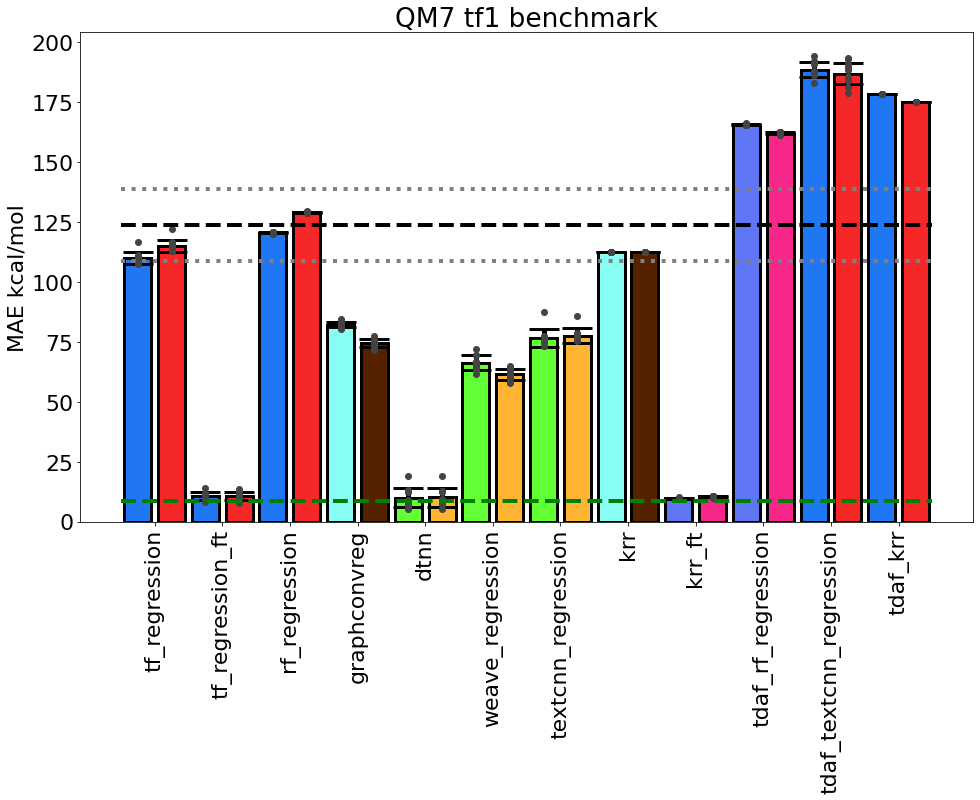

In [431]:
ax, means, stds= method_comparison_plotter(
    list_of_dataframes=all_dfs,
    list_of_columns=['val_mae','te_mae'],
    color_list=None,
    exclusion_list=[],
    filename='tf1_benchmark',
    label_list=model_name_list+['tdaf_' + x for x in tdaf_model_name_list],
    best_con=best_con,
    best_con_error=15,
    best_gr=best_graph,
    best_gr_error=None,
    x_label='',
    y_label='MAE kcal/mol',
    rider='all_data_with_tdaf.png')
plt.title('QM7 tf1 benchmark')

In [52]:
20*10 +20*20+127+2*127+10*119+2*72+3*67+2*440

3396

In [445]:
x=[92,83]
print(np.mean(x))
print(np.std(x))




87.5
4.5


In [461]:
x = 82.5
y = 4.5
x+y,x-y

(87.0, 78.0)

In [458]:
74+1.2

75.2

70.9